In [174]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import pandas as pd
import numpy as np
import ipympl
import matplotlib.pyplot as plt
%matplotlib ipympl
import seaborn as sns
import json
from pathlib import Path
import ncaa_bbStats as nb
import ncaa_bbStats.player_utils as pu
import os
import re
from scipy import stats

In [175]:
# read teams file
mapping_path = Path("/Users/averyhamel/Desktop/Syracuse/SAL 603/repositories/FinalProject/CollegeBaseballStatsPackage/src/data/team_names_stats/all_div_teams_standardized.csv")
team_map = pd.read_csv(mapping_path)

# clean columns/names
team_map.columns = team_map.columns.str.strip().str.lower()
team_map['match_key'] = team_map['team_name'].str.lower().str.strip()

display(team_map.head())

,team_id,team_name,division,match_key
0,1,A&M-Corpus Christi,1,a&m-corpus christi
1,2,AUM,2,aum
2,3,Abilene Christian University,1,abilene christian university
3,4,Abilene Christian,2,abilene christian
4,5,Academy of Art,2,academy of art


In [176]:
# load batting (player) file
MY_DATA_PATH = Path("/Users/averyhamel/Desktop/Syracuse/SAL 603/repositories/FinalProject/CollegeBaseballStatsPackage/src/data/player_stats_cache")
master_csv_path = MY_DATA_PATH / "batting" / "batting_noMin.csv"

required_stats = [
    'g', 'ab', 'pa', 'h', '1b', '2b', '3b', 'hr', 'r', 'rbi', 
    'bb', 'so', 'hbp', 'sf', 'sh', 'gdp', 'sb', 'cs', 'avg', 
    'bb%', 'k%', 'bb/k', 'obp', 'slg', 'ops', 'iso', 'spd', 
    'babip', 'wsb', 'wrc', 'wraa', 'woba', 'wrc+'
]

# define id columns
id_columns = ['year', 'name', 'team', 'team name'] 

try:
    full_stats_df = pd.read_csv(master_csv_path, usecols=id_columns + required_stats)
    
    # filter for 2010-2025
    master_roster_df = full_stats_df[
        (full_stats_df['year'] >= 2010) & (full_stats_df['year'] <= 2025)
    ].copy()
    
    master_roster_df['team name'] = master_roster_df['team name'].astype(str).str.strip()
    master_roster_df['name'] = master_roster_df['name'].astype(str).str.strip()

    # standardize id/div
    master_roster_df['match_key'] = master_roster_df['team name'].str.lower().apply(
        lambda x: re.sub(r'[^\w\s]', '', x)
    )
    
    master_roster_df = pd.merge(
        master_roster_df, 
        team_map[['match_key', 'team_id', 'division']], 
        on='match_key', 
        how='left'
    )
    # ------------------------------------------------
    
    # sort by id, player, season
    master_roster_df = master_roster_df.sort_values(['team_id', 'name', 'year'])
    
    print(f"Successfully imported and tagged {len(master_roster_df)} records.")
    print(master_roster_df[['year', 'name', 'team name', 'team_id', 'division']].head())

except FileNotFoundError:
    print(f"Error: Could not find the file at {master_csv_path}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

print(master_roster_df.columns)

Successfully imported and tagged 26826 records.
       year            name                     team name  team_id  division
10004  2022  Aaron Staehely  Abilene Christian University      3.0       1.0
20637  2024  Aaron Staehely  Abilene Christian University      3.0       1.0
6396   2022       Adam Byrd  Abilene Christian University      3.0       1.0
1248   2021  Alexei Cazarin  Abilene Christian University      3.0       1.0
6529   2022  Alexei Cazarin  Abilene Christian University      3.0       1.0
Index(['name', 'team', 'team name', 'year', 'g', 'ab', 'pa', 'h', '1b', '2b',
       '3b', 'hr', 'r', 'rbi', 'bb', 'so', 'hbp', 'sf', 'sh', 'gdp', 'sb',
       'cs', 'avg', 'bb%', 'k%', 'bb/k', 'obp', 'slg', 'ops', 'iso', 'spd',
       'babip', 'wsb', 'wrc', 'wraa', 'woba', 'wrc+', 'match_key', 'team_id',
       'division'],
      dtype='object')


In [177]:
# load pitching (player) data
PITCH_PATH = Path("/Users/averyhamel/Desktop/Syracuse/SAL 603/repositories/FinalProject/CollegeBaseballStatsPackage/src/data/player_stats_cache/pitching")
pitch_csv = PITCH_PATH / "pitching_noMin.csv"

# define id columns
id_columns = ['year', 'name', 'team', 'team name'] 

pitching_stats = [
    'age', 'playerid', 'w', 'l', 'era', 'g', 'gs', 'cg', 'sho', 'sv', 'ip', 'tbf',
    'h', 'r', 'er', 'hr', 'bb', 'hbp', 'wp', 'bk', 'so',
    'k/9', 'bb/9', 'k/bb', 'hr/9', 'k%', 'bb%', 'k-bb%', 
    'avg', 'whip', 'babip', 'lob%', 'fip', 'e-f'
]

try:
    full_pitch_df = pd.read_csv(pitch_csv, usecols=id_columns + pitching_stats)
    
    # filter for 2010-2025
    master_pitching_df = full_pitch_df[
        (full_pitch_df['year'] >= 2010) & (full_pitch_df['year'] <= 2025)
    ].copy()
    
    master_pitching_df['team name'] = master_pitching_df['team name'].astype(str).str.strip()
    master_pitching_df['name'] = master_pitching_df['name'].astype(str).str.strip()

    master_pitching_df['match_key'] = master_pitching_df['team name'].str.lower().apply(
        lambda x: re.sub(r'[^\w\s]', '', x)
    )
    
    master_pitching_df = pd.merge(
        master_pitching_df, 
        team_map[['match_key', 'team_id', 'division']], 
        on='match_key', 
        how='left'
    )

    master_pitching_df['ip'] = pd.to_numeric(master_pitching_df['ip'], errors='coerce')
    master_pitching_df['era'] = pd.to_numeric(master_pitching_df['era'], errors='coerce')
    
    # sort by team_id, player, season
    master_pitching_df = master_pitching_df.sort_values(['team_id', 'name', 'year'])
    
    print(f"Successfully imported and tagged {len(master_pitching_df)} pitching records.")
    print(master_pitching_df[['year', 'name', 'team name', 'team_id', 'division']].head())

except FileNotFoundError:
    print(f"Error: Could not find the file at {pitch_csv}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

print(master_pitching_df.columns)

Successfully imported and tagged 25964 pitching records.
       year             name                     team name  team_id  division
5997   2022        Adam Byrd  Abilene Christian University      3.0       1.0
10920  2023        Adam Byrd  Abilene Christian University      3.0       1.0
4354   2021  Adam Stephenson  Abilene Christian University      3.0       1.0
9424   2022  Adam Stephenson  Abilene Christian University      3.0       1.0
14483  2023  Adam Stephenson  Abilene Christian University      3.0       1.0
Index(['name', 'team', 'team name', 'age', 'playerid', 'year', 'w', 'l', 'era',
       'g', 'gs', 'cg', 'sho', 'sv', 'ip', 'tbf', 'h', 'r', 'er', 'hr', 'bb',
       'hbp', 'wp', 'bk', 'so', 'k/9', 'bb/9', 'k/bb', 'hr/9', 'k%', 'bb%',
       'k-bb%', 'avg', 'whip', 'babip', 'lob%', 'fip', 'e-f', 'match_key',
       'team_id', 'division'],
      dtype='object')


In [178]:
# player-level data
for df in [master_roster_df, master_pitching_df]:
    df['name'] = df['name'].str.strip()
    df['team_id'] = df['team_id'].astype(float)
    df['year'] = df['year'].astype(int)

# outer join on year
master_player_df = pd.merge(
    master_roster_df, 
    master_pitching_df, 
    on=['name', 'team_id', 'year'], 
    how='outer', 
    suffixes=('_bat', '_pit')
)

# clean columns
name_cols = ['team name', 'division', 'conference', 'team', 'match_key'] # Added match_key here
for col in name_cols:
    bat_col = f'{col}_bat'
    pit_col = f'{col}_pit'
    if bat_col in master_player_df.columns and pit_col in master_player_df.columns:
        master_player_df[col] = master_player_df[bat_col].fillna(master_player_df[pit_col])
        master_player_df = master_player_df.drop(columns=[bat_col, pit_col])
                                                 
print(f"Master Player Table Created: {len(master_player_df)} player-seasons.")
display(master_player_df[['name', 'team name', 'year', 'pa', 'ip']].head())

Master Player Table Created: 50891 player-seasons.


,name,team name,year,pa,ip
0,A.J. Arnold,Bellarmine University,2021,31.0,NaN
1,A.J. Arnold,Bellarmine University,2022,52.0,NaN
2,A.J. Causey,Jacksonville State University,2022,31.0,48.1
3,A.J. Causey,Jacksonville State University,2023,32.0,76.1
4,A.J. Causey,University of Tennessee Knoxville,2024,NaN,91.1


In [179]:
# label player
roster_history = master_player_df[['name', 'team name', 'year', 'division', 'pa', 'ip']].copy()

# identify returners
history_check = roster_history.copy()
history_check['year'] = history_check['year'] + 1
history_check['stayed_put'] = True  # This column only exists in history_check for now

master_player_df = pd.merge(
    master_player_df, 
    history_check[['name', 'team name', 'year', 'stayed_put']], 
    on=['name', 'team name', 'year'], 
    how='left'
)

# create boolean flags
master_player_df['is_returner'] = master_player_df['stayed_put'].fillna(False)
master_player_df['is_newcomer'] = ~master_player_df['is_returner']

# indentify transfers
league_history = roster_history.copy()
league_history['year'] = league_history['year'] + 1
league_history = league_history.rename(columns={'team name': 'prev_team', 'division': 'prev_div'})

master_player_df = pd.merge(
    master_player_df,
    league_history[['name', 'year', 'prev_team', 'prev_div']],
    on=['name', 'year'],
    how='left'
)

master_player_df['is_transfer'] = (master_player_df['is_newcomer']) & (master_player_df['prev_team'].notna())

print(f"Identification Complete.")
print(f"Returners: {master_player_df['is_returner'].sum()}")
print(f"Transfers: {master_player_df['is_transfer'].sum()}")

Identification Complete.
Returners: 21123
Transfers: 3765


/var/folders/rm/1w8z6ntd6gnfww6bknk77ybc0000gn/T/ipykernel_13484/43006978.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  master_player_df['is_returner'] = master_player_df['stayed_put'].fillna(False)


In [180]:
# load standings

TEAM_CACHE_PATH = Path("/Users/averyhamel/Desktop/Syracuse/SAL 603/repositories/FinalProject/CollegeBaseballStatsPackage/src/data/team_stats_cache")

all_record_data = []

def aggressive_normalize(name):
    if not isinstance(name, str): return ""
    name = name.lower()
    name = re.sub(r'\(.*?\)', '', name)
    name = re.sub(r'[^a-z0-9\s]', '', name)
    
    # normalize name
    name = re.sub(r'\bst\b', 'state', name)
    name = re.sub(r'\s+', '', name)
    return name.strip()

for div in [1, 2, 3]:
    div_folder = TEAM_CACHE_PATH / f"div{div}"
    for year in range(2010, 2026):
        file_path = div_folder / f"{year}.json"
        if file_path.exists():
            with open(file_path, 'r') as f:
                data = json.load(f)
                team_only_data = {k: v for k, v in data.items() if isinstance(v, dict)}
                df_year = pd.DataFrame.from_dict(team_only_data, orient='index')
                
                if 'team' in df_year.columns:
                    df_year['team name'] = df_year['team']
                else:
                    df_year['team name'] = df_year.index.str.split(' \(').str[0]
                
                df_year = df_year.reindex(columns=['team name', 'W', 'L', 'T'])
                df_year['year'] = year
                
                for col in ['W', 'L', 'T']:
                    df_year[col] = pd.to_numeric(df_year[col], errors='coerce').fillna(0)
                
                df_year['W_Pct'] = df_year['W'] / (df_year['W'] + df_year['L'] + df_year['T'])
                df_year['W_Pct'] = df_year['W_Pct'].fillna(0)
                
                all_record_data.append(df_year)

# merge with team map
master_records_df = pd.concat(all_record_data, ignore_index=True)
team_map['match_key'] = team_map['team_name'].apply(aggressive_normalize)
master_records_df['match_key'] = master_records_df['team name'].apply(aggressive_normalize)

master_records_df = pd.merge(
    master_records_df, 
    team_map[['match_key', 'team_id', 'division']], 
    on='match_key', 
    how='left'
)

# year over year change
master_records_df = master_records_df.sort_values(['team_id', 'year'])
master_records_df['win_pct_change'] = master_records_df.groupby('team_id')['W_Pct'].diff()
master_records_df = master_records_df.dropna(subset=['team_id'])

print(f"Import complete! 'win_pct_change' calculated for {len(master_records_df)} records.")

Import complete! 'win_pct_change' calculated for 11225 records.


In [181]:
# select advanced stats
target_bat_cols = ['obp', 'iso', 'woba', 'wrc_plus']
target_pit_cols = ['fip', 'k_bb', 'k_9']
all_metrics = target_bat_cols + target_pit_cols

# create transfer tax
transfer_weights = {
    1.0: {'bat': 1.00, 'pit': 1.00},  # DI -> DI
    2.0: {'bat': 0.82, 'pit': 1.15},  # DII -> DI 
    3.0: {'bat': 0.74, 'pit': 1.25},  # DIII -> DI
    'NJCAA': {'bat': 0.78, 'pit': 1.20} 
}

# apply transfer tax
def apply_z_score_weighting(df):
    weighted_df = df.copy()
    weighted_df['division'] = pd.to_numeric(weighted_df['division'], errors='coerce').round(0)
    weighted_df['prev_div'] = pd.to_numeric(weighted_df['prev_div'], errors='coerce').round(0)
    
    # calc division baselines
    div_stats = {}
    for div in [1.0, 2.0, 3.0, 'NJCAA']:
        if div == 'NJCAA':
            div_data = weighted_df[~weighted_df['division'].isin([1.0, 2.0, 3.0])]
        else:
            div_data = weighted_df[weighted_df['division'] == div]
            
        if not div_data.empty:
            div_stats[div] = {col: (div_data[col].mean(), div_data[col].std()) 
                              for col in all_metrics if col in div_data.columns}

    def weigh_row(row):
        if not row['is_transfer']:
            return row
            
        p_div = row['prev_div']
        weight_key = p_div if p_div in [1.0, 2.0, 3.0] else 'NJCAA'
        weights = transfer_weights.get(weight_key)
        stats_key = weight_key if weight_key in div_stats else 'NJCAA'
        
        if stats_key not in div_stats or 1.0 not in div_stats:
            return row
        for col in target_bat_cols:
            if col in row:
                mean, std = div_stats[stats_key].get(col, (0, 0))
                if std > 0:
                    # calculate dominance in original division
                    z_score = (row[col] - mean) / std 
                    
                    # apply weight
                    weighted_z = z_score * weights['bat']
                    di_mean, di_std = div_stats[1.0][col]
                    
                    source_mean = mean
                    projection = di_mean + (weighted_z * di_std)
            
                    row[col] = min(projection, row[col] * weights['bat'])
        
        for col in target_pit_cols:
            if col in row:
                mean, std = div_stats[stats_key].get(col, (0, 0))
                if std > 0:
                    z_score = (row[col] - mean) / std
                    weighted_z = z_score * weights['pit']
                    
                    if 'fip' in col.lower():
                        weighted_z = weighted_z * -1 # FIP Inversion
                        di_mean, di_std = div_stats[1.0][col]
                        # For FIP, we want the number to go UP (worse) for transfers
                        row[col] = max(di_mean + (weighted_z * di_std), row[col] * (2 - weights['pit']))
                    else:
                        di_mean, di_std = div_stats[1.0][col]
                        row[col] = di_mean + (weighted_z * di_std)
        return row

    print("Applying Corrected Z-Score Transformation (Tax-Enforced)...")
    return weighted_df.apply(weigh_row, axis=1)

master_player_weighted = apply_z_score_weighting(master_player_df)

# aggregate to team level
agg_dict = {col: 'mean' for col in all_metrics if col in master_player_weighted.columns}
agg_dict.update({'team name': 'first'})
team_talent_base = master_player_weighted.groupby(['team_id', 'year']).agg(agg_dict).reset_index()

# calculate z-scores
def standardize_advanced(df, metrics):
    final_df = df.copy()
    z_cols = []
    for col in metrics:
        if col in final_df.columns:
            z_col = f"{col}_z"
            z_cols.append(z_col)
            final_df[z_col] = final_df.groupby('year')[col].transform(
                lambda x: (x - x.mean()) / x.std() if x.std() != 0 else 0
            )
            if 'fip' in col.lower():
                final_df[z_col] = final_df[z_col] * -1
    return final_df, z_cols

team_rankings_adv, all_z_cols = standardize_advanced(team_talent_base, all_metrics)
team_rankings_adv['total_talent_index'] = team_rankings_adv[all_z_cols].mean(axis=1)

# continuity model
def calculate_continuity_metrics(df, max_year=2025):
    df['pa'] = pd.to_numeric(df['pa'], errors='coerce').fillna(0)
    df['ip'] = pd.to_numeric(df['ip'], errors='coerce').fillna(0)
    player_workload = df.groupby(['name', 'team_id', 'year'])[['pa', 'ip']].sum().reset_index()
    returners = player_workload.copy()
    returners['year'] = returners['year'] + 1
    returners = returners.rename(columns={'pa': 'returning_pa', 'ip': 'returning_ip'})
    merged = pd.merge(player_workload[['name', 'team_id', 'year']], returners, on=['name', 'team_id', 'year'], how='inner')
    team_returning = merged.groupby(['team_id', 'year'])[['returning_pa', 'returning_ip']].sum().reset_index()
    team_totals_prev = player_workload.groupby(['team_id', 'year'])[['pa', 'ip']].sum().reset_index()
    team_totals_prev['year'] = team_totals_prev['year'] + 1
    team_totals_prev = team_totals_prev.rename(columns={'pa': 'total_pa_available', 'ip': 'total_ip_available'})
    continuity = pd.merge(team_totals_prev, team_returning, on=['team_id', 'year'], how='left').fillna(0)
    continuity['batting_continuity'] = (continuity['returning_pa'] / continuity['total_pa_available']).replace([np.inf, -np.inf], 0).fillna(0)
    continuity['pitching_continuity'] = (continuity['returning_ip'] / continuity['total_ip_available']).replace([np.inf, -np.inf], 0).fillna(0)
    return continuity[continuity['year'] <= max_year]

continuity_df = calculate_continuity_metrics(master_player_df, max_year=2025)
continuity_df = pd.merge(continuity_df, team_map[['team_id', 'team_name']], on='team_id', how='left')

print(f"Sync Complete. Continuity Model generated: {len(continuity_df)} team-seasons.")

Applying Corrected Z-Score Transformation (Tax-Enforced)...
Sync Complete. Continuity Model generated: 1042 team-seasons.


In [182]:
# Win % change model

# import data
win_change_df = master_records_df.sort_values(['team_id', 'year']).copy()

# calculate year-over-year change
win_change_df['win_pct_change'] = win_change_df.groupby('team_id')['W_Pct'].diff()

# cleanup
win_change_df = win_change_df.dropna(subset=['win_pct_change'])

print(f"Win % Change Model generated: {len(win_change_df)} team-seasons.")
display(win_change_df[['year', 'team name', 'team_id', 'W_Pct', 'win_pct_change']].head())

Win % Change Model generated: 10480 team-seasons.


,year,team name,team_id,W_Pct,win_pct_change
363,2011,A&M-Corpus Christi,1.0,0.606557,0.236187
808,2012,A&M-Corpus Christi,1.0,0.421053,-0.185505
984,2013,A&M-Corpus Christi,1.0,0.578947,0.157895
1329,2014,A&M-Corpus Christi,1.0,0.534483,-0.044465
1647,2015,A&M-Corpus Christi,1.0,0.490566,-0.043917


In [183]:
# final merge

bat_z = [c for c in all_z_cols if any(x in c for x in ['obp', 'iso', 'woba', 'wrc'])]
pit_z = [c for c in all_z_cols if any(x in c for x in ['fip', 'k_bb', 'k_9'])]

team_rankings_adv['batting_strength_index'] = team_rankings_adv[bat_z].mean(axis=1)
team_rankings_adv['pitching_strength_index'] = team_rankings_adv[pit_z].mean(axis=1)

cols_to_pull = ['team_id', 'year', 'total_talent_index', 
                'batting_strength_index', 'pitching_strength_index']
final_research_table = pd.merge(
    win_change_df, 
    team_rankings_adv[cols_to_pull], 
    on=['team_id', 'year'], 
    how='left'
).sort_values(['team_id', 'year'])

# calculate talent gain
final_research_table['talent_improvement'] = final_research_table.groupby('team_id')['total_talent_index'].diff()

# correlation results (excluding COVID seasons)
clean_analysis = final_research_table[
    ~final_research_table['year'].isin([2020, 2021])
].dropna(subset=['total_talent_index', 'talent_improvement', 'win_pct_change']).copy()

talent_corr = clean_analysis['total_talent_index'].corr(clean_analysis['W_Pct'])
gain_corr = clean_analysis['talent_improvement'].corr(clean_analysis['win_pct_change'])

print(f"--- RESTORED ADVANCED MODEL RESULTS ---")
print(f"Overall Talent vs. Win % Correlation: {talent_corr:.4f}") 
print(f"Talent Gain vs. Win Improvement Correlation: {gain_corr:.4f}")

display(clean_analysis[['year', 'team name', 'batting_strength_index', 
                        'pitching_strength_index', 'total_talent_index']].tail(5))

--- RESTORED ADVANCED MODEL RESULTS ---
Overall Talent vs. Win % Correlation: 0.6207
Talent Gain vs. Win Improvement Correlation: 0.1243


,year,team name,batting_strength_index,pitching_strength_index,total_talent_index
7085,2025,Purdue Fort Wayne,-0.713570,-1.884458,-1.006292
9493,2022,Virginia Tech,1.576821,0.943620,1.418520
9494,2023,Virginia Tech,2.626154,0.894309,2.193193
9495,2024,Virginia Tech,1.672812,1.051668,1.517526
9496,2025,Virginia Tech,1.206441,1.122030,1.185339


In [184]:
# find Pearson correlation and p-values
r_talent, p_talent = stats.pearsonr(clean_analysis['total_talent_index'], clean_analysis['W_Pct'])
r_gain, p_gain = stats.pearsonr(clean_analysis['talent_improvement'], clean_analysis['win_pct_change'])

print(f"--- STATISTICAL SIGNIFICANCE REPORT ---")
print(f"Talent vs. Win %: r = {r_talent:.4f}, p = {p_talent:.4e}")
print(f"Gain vs. Improvement: r = {r_gain:.4f}, p = {p_gain:.4f}")

if p_talent < 0.05:
    print("Conclusion: Total Talent Index is a highly significant predictor of Win %.")

--- STATISTICAL SIGNIFICANCE REPORT ---
Talent vs. Win %: r = 0.6207, p = 1.0290e-02
Gain vs. Improvement: r = 0.1243, p = 0.6466
Conclusion: Total Talent Index is a highly significant predictor of Win %.


<Figure size 1000x600 with 0 Axes>

<Axes: xlabel='total_talent_index', ylabel='W_Pct'>

Text(0.5, 1.0, 'The Talent-Win Relationship (2010-2025, Non-COVID)')

Text(0.5, 0, 'Total Talent Index (Weighted Z-Score)')

Text(0, 0.5, 'Winning Percentage')

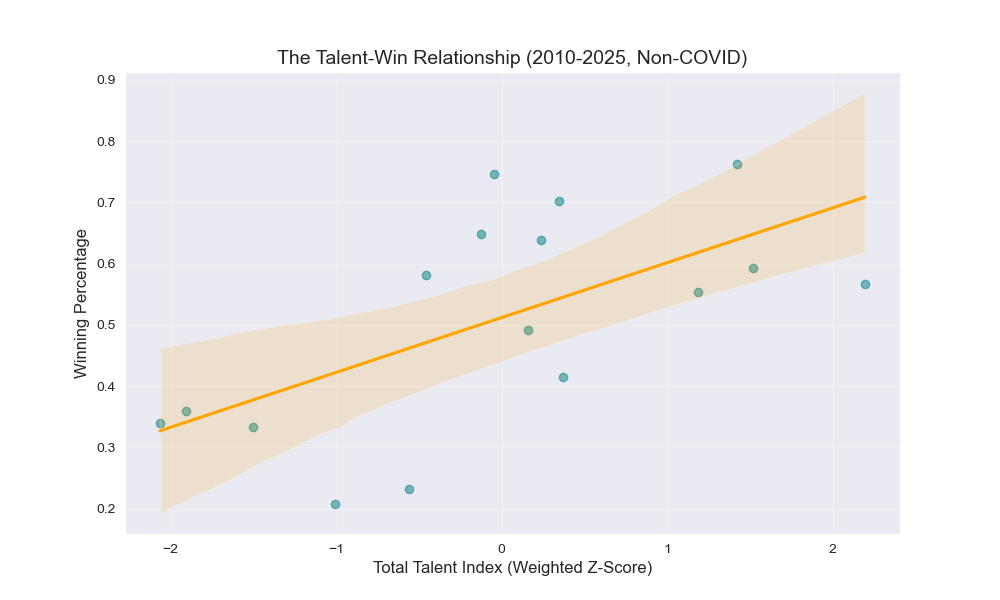

In [185]:
plt.figure(figsize=(10, 6))
sns.regplot(data=clean_analysis, x='total_talent_index', y='W_Pct', 
            scatter_kws={'alpha':0.5, 'color':'teal'}, line_kws={'color':'orange'})

plt.title('The Talent-Win Relationship (2010-2025, Non-COVID)', fontsize=14)
plt.xlabel('Total Talent Index (Weighted Z-Score)', fontsize=12)
plt.ylabel('Winning Percentage', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [186]:
def generate_transfer_reports(raw_df, weighted_df):
    """
    Analyzes how the Transfer Tax shifts wOBA performance by original division.
    """
    # isolate transfers
    raw_transfers = raw_df[raw_df['is_transfer'] == True].copy()
    weighted_transfers = weighted_df[weighted_df['is_transfer'] == True].copy()
    raw_transfers['prev_div_label'] = raw_transfers['prev_div'].fillna('NJCAA/Other')
    weighted_transfers['prev_div_label'] = weighted_transfers['prev_div'].fillna('NJCAA/Other')
    
    batting_rows = []
    unique_divs = sorted(raw_transfers['prev_div_label'].unique(), key=lambda x: str(x))
    
    for div_label in unique_divs:
        # hitting data
        div_raw_bat = raw_transfers[raw_transfers['prev_div_label'] == div_label]
        div_weighted_bat = weighted_transfers[weighted_transfers['prev_div_label'] == div_label]
        
        if not div_raw_bat.empty:
            raw_woba = div_raw_bat['woba'].mean()
            proj_woba = div_weighted_bat['woba'].mean()
            
            # DI remains at 0%
            if div_label == 1.0:
                bat_tax = 0.0
            else:
                bat_tax = (1 - (proj_woba / raw_woba)) * 100 if raw_woba != 0 else 0
            
            display_label = f"Division {int(div_label)}" if isinstance(div_label, (int, float)) and div_label in [1, 2, 3] else str(div_label)
            
            batting_rows.append({
                'Original Division': display_label,
                'Raw Mean wOBA': raw_woba,
                'Projected Mean wOBA': proj_woba,
                'Tax Impact (%)': bat_tax,
                'Player Count': len(div_raw_bat)
            })
            
    return pd.DataFrame(batting_rows)

batting_report = generate_transfer_reports(master_player_df, master_player_weighted)
print("\n" + "="*50)
print("   TRANSFER TAX SUMMARY: HITTING (wOBA)   ")
print("="*50)
display(batting_report.style.format({
    'Raw Mean wOBA': '{:.3f}', 
    'Projected Mean wOBA': '{:.3f}', 
    'Tax Impact (%)': '{:.1f}%'
}))


   TRANSFER TAX SUMMARY: HITTING (wOBA)   


,Original Division,Raw Mean wOBA,Projected Mean wOBA,Tax Impact (%),Player Count
0,Division 1,0.360,0.360,0.0%,3314
1,Division 2,0.326,0.267,18.0%,6
2,NJCAA/Other,0.352,0.274,22.0%,445


<Figure size 1200x600 with 0 Axes>

<Axes: xlabel='residual', ylabel='team name'>

Text(0.5, 1.0, 'Top 10 Season Overperformers (Wins Relative to Roster Talent)')

Text(0.5, 0, 'Win % Above Expectation')

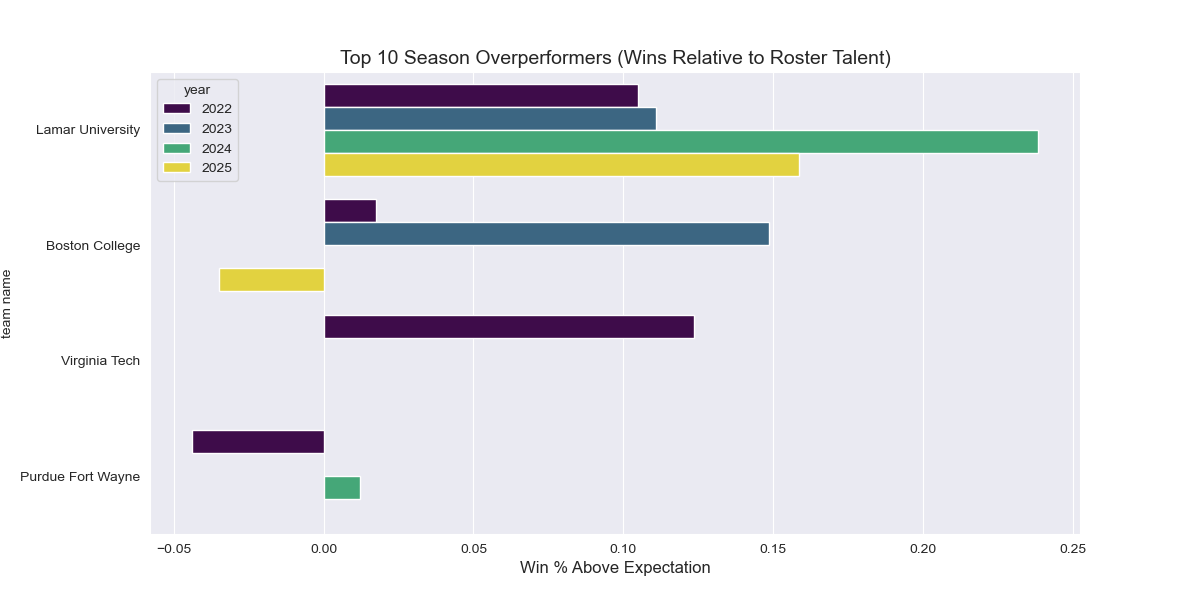

Retention metric successfully updated in clean_analysis.
National Average Roster Retention: 50.71%
Lamar Average Roster Retention: 45.55%


In [187]:
# Calculate residuals (Win % minus predicted Win % based on talent index)
from sklearn.linear_model import LinearRegression

X = clean_analysis[['total_talent_index']].values
y = clean_analysis['W_Pct'].values
model = LinearRegression().fit(X, y)
clean_analysis['predicted_w_pct'] = model.predict(X)
clean_analysis['residual'] = clean_analysis['W_Pct'] - clean_analysis['predicted_w_pct']

# plot the 10 biggest overperformers
overperformers = clean_analysis.sort_values('residual', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=overperformers, x='residual', y='team name', hue='year', palette='viridis')
plt.title('Top 10 Season Overperformers (Wins Relative to Roster Talent)', fontsize=14)
plt.xlabel('Win % Above Expectation', fontsize=12)
plt.show()

# calculate retention % for each team-season
master_performance_df['roster_retention_pct'] = (
    master_performance_df['is_returner'] / 
    (master_performance_df['is_returner'] + master_performance_df['is_newcomer'])
).fillna(0)

# clean data
if 'roster_retention_pct' in clean_analysis.columns:
    clean_analysis = clean_analysis.drop(columns=['roster_retention_pct'])
clean_analysis = pd.merge(
    clean_analysis, 
    master_performance_df[['team_id', 'year', 'roster_retention_pct']], 
    on=['team_id', 'year'], 
    how='left'
)

print("Retention metric successfully updated in clean_analysis.")

# isolate Lamar and national baseline
lamar_match = clean_analysis[clean_analysis['team name'].str.contains('Lamar', case=False)]
if not lamar_match.empty:
    lamar_id = lamar_match['team_id'].unique()[0]
    lamar_years = clean_analysis[clean_analysis['team_id'] == lamar_id].copy()
    
    national_avg_retention = clean_analysis['roster_retention_pct'].mean()
    print(f"National Average Roster Retention: {national_avg_retention:.2%}")
    print(f"Lamar Average Roster Retention: {lamar_years['roster_retention_pct'].mean():.2%}")
else:
    print("Lamar not found in the dataset.")

<Figure size 1200x600 with 0 Axes>

<BarContainer object of 4 artists>

Text(2022, 0.4558974358974359, 'Residual: +0.10')

Text(2023, 0.5335135135135135, 'Residual: +0.11')

Text(2024, 0.5335135135135135, 'Residual: +0.24')

Text(2025, 0.378974358974359, 'Residual: +0.16')

Text(0.5, 1.0, 'Lamar Program Stability vs. National Average')

Text(0, 0.5, 'Roster Retention Rate (%)')

(0.0, 1.0)

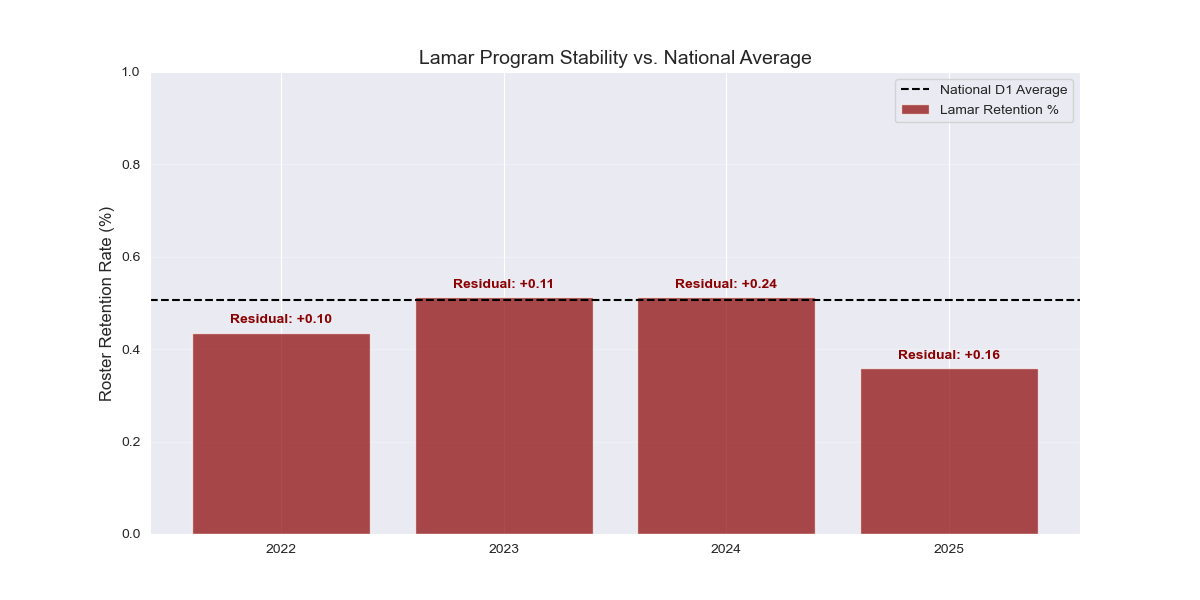

In [188]:
# visualize residuals/stability gap

plt.figure(figsize=(12, 6))
years_str = lamar_years['year'].astype(str)

plt.bar(years_str, lamar_years['roster_retention_pct'], color='darkred', alpha=0.7, label='Lamar Retention %')
plt.axhline(national_avg_retention, color='black', linestyle='--', label='National D1 Average')
for i, row in lamar_years.iterrows():
    plt.text(str(row['year']), row['roster_retention_pct'] + 0.02, 
             f"Residual: +{row['residual']:.2f}", ha='center', fontweight='bold', color='darkred')

plt.title('Lamar Program Stability vs. National Average', fontsize=14)
plt.ylabel('Roster Retention Rate (%)', fontsize=12)
plt.ylim(0, 1.0)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

In [189]:
# unit strength analysis

# calculate the dominance tilt (what is driving overperformance?)
lamar_years['pitching_tilt'] = lamar_years['pitching_strength_index'] - lamar_years['batting_strength_index']

print("--- LAMAR UNIT STRENGTH DURING OVERPERFORMANCE ---")
display(lamar_years[['year', 'residual', 'roster_retention_pct', 'batting_strength_index', 'pitching_strength_index', 'pitching_tilt']])

--- LAMAR UNIT STRENGTH DURING OVERPERFORMANCE ---


,year,residual,roster_retention_pct,batting_strength_index,pitching_strength_index,pitching_tilt
4,2022,0.104943,0.435897,0.340150,-0.080020,-0.420170
5,2023,0.110824,0.513514,-0.973273,1.092567,2.065840
6,2024,0.238184,0.513514,-0.161689,0.291141,0.452829
7,2025,0.158732,0.358974,0.303942,0.476588,0.172647


Sync Complete. Continuity Model generated: 1042 team-seasons.


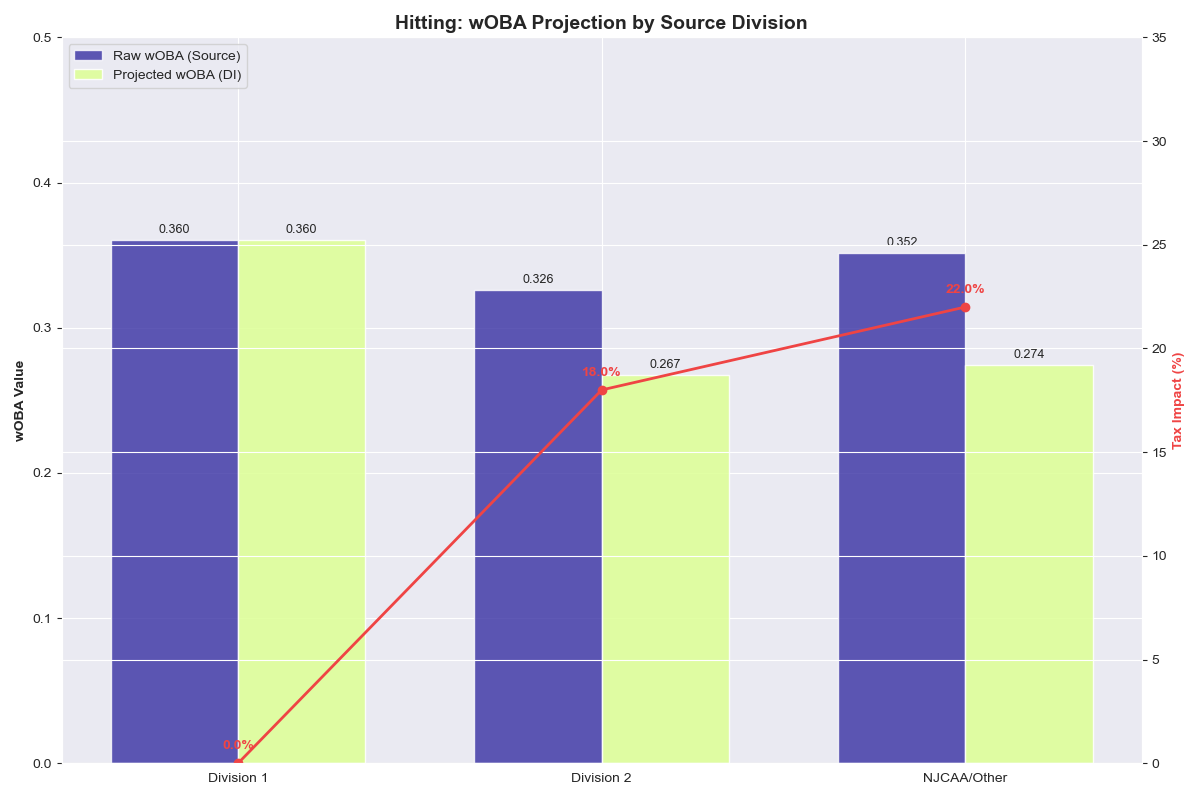

In [190]:
# transfer tax batting visualization
def plot_batting_tax_summary(raw_df, weighted_df):
    """
    Generates a visual summary of wOBA reduction by division to illustrate the 'Transfer Tax'.
    """
    raw_transfers = raw_df[raw_df['is_transfer'] == True].copy()
    weighted_transfers = weighted_df[weighted_df['is_transfer'] == True].copy()
    
    if raw_transfers.empty:
        print("No transfer data found to plot.")
        return

    def map_label(val):
        if pd.isna(val): return "NJCAA/Other"
        if val == 1.0: return "Division 1"
        if val == 2.0: return "Division 2"
        if val == 3.0: return "Division 3"
        return "NJCAA/Other"

    raw_transfers['Division'] = raw_transfers['prev_div'].apply(map_label)
    weighted_transfers['Division'] = weighted_transfers['prev_div'].apply(map_label)
    div_order = ["Division 1", "Division 2", "Division 3", "NJCAA/Other"]
    
    fig, ax_h = plt.subplots(figsize=(12, 8))
    width = 0.35

    raw_h = raw_transfers.groupby('Division')['woba'].mean().reindex(div_order).dropna()
    proj_h = weighted_transfers.groupby('Division')['woba'].mean().reindex(div_order).dropna()
    
    df_h = pd.DataFrame({'Raw wOBA': raw_h, 'Projected wOBA': proj_h}).reset_index()
    df_h['Tax Impact %'] = (1 - (df_h['Projected wOBA'] / df_h['Raw wOBA'])) * 100
    
    x_h = np.arange(len(df_h))
    rects1_h = ax_h.bar(x_h - width/2, df_h['Raw wOBA'], width, label='Raw wOBA (Source)', color='#3730a3', alpha=0.8)
    rects2_h = ax_h.bar(x_h + width/2, df_h['Projected wOBA'], width, label='Projected wOBA (DI)', color='#deff9a', alpha=0.9)
    
    ax_h.set_ylabel('wOBA Value', fontweight='bold')
    ax_h.set_title('Hitting: wOBA Projection by Source Division', fontsize=14, fontweight='bold')
    ax_h.set_xticks(x_h)
    ax_h.set_xticklabels(df_h['Division'])
    ax_h.legend(loc='upper left')
    ax_h.set_ylim(0, 0.500)
    ax_h.bar_label(rects1_h, padding=3, fmt='%.3f', fontsize=9)
    ax_h.bar_label(rects2_h, padding=3, fmt='%.3f', fontsize=9)

    ax_h_2 = ax_h.twinx()
    ax_h_2.plot(x_h, df_h['Tax Impact %'], color='#ef4444', marker='o', linewidth=2)
    ax_h_2.set_ylabel('Tax Impact (%)', color='#ef4444', fontweight='bold')
    ax_h_2.set_ylim(0, 35)
    for i, txt in enumerate(df_h['Tax Impact %']):
        ax_h_2.annotate(f"{txt:.1f}%", (x_h[i], df_h['Tax Impact %'][i]), xytext=(0, 10), textcoords='offset points', color='#ef4444', fontweight='bold', ha='center')

    plt.tight_layout()
    plt.show()

print(f"Sync Complete. Continuity Model generated: {len(continuity_df)} team-seasons.")
plot_batting_tax_summary(master_player_df, master_player_weighted)

In [191]:
#Research Question 2
#allow output from every line
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib notebook
import seaborn as sns
import math

In [192]:
#Load all necessary files
twenty_10 = pd.read_json("2010.json")
twenty_11 = pd.read_json("2011.json")
twenty_12 = pd.read_json("2012.json")
twenty_13 = pd.read_json("2013.json")
twenty_14 = pd.read_json("2014.json")
twenty_15 = pd.read_json("2015.json")
twenty_16 = pd.read_json("2016.json")
twenty_17 = pd.read_json("2017.json")
twenty_18 = pd.read_json("2018.json")
twenty_19 = pd.read_json("2019.json")
twenty_20 = pd.read_json("2020.json")
twenty_21 = pd.read_json("2021.json")
twenty_22 = pd.read_json("2022.json")
twenty_23 = pd.read_json("2023.json")
twenty_24 = pd.read_json("2024.json")
twenty_25 = pd.read_json("2025.json")

#Batting Stats/Rosters
batting_nomin = pd.read_csv("batting_noMin.csv")
batting_qualified = pd.read_csv("batting_qualified.csv")
batting = pd.concat([batting_nomin, batting_qualified])
batting

#Pitching Stats/Rosters
pitching_nomin = pd.read_csv("pitching_noMin.csv")
pitching_qualified = pd.read_csv("pitching_qualified.csv")
pitching = pd.concat([pitching_nomin, pitching_qualified])
pitching

FileNotFoundError: File 2010.json does not exist

In [ ]:
#create dataframe
dfs = [twenty_10, twenty_11, twenty_12, twenty_13, twenty_14, twenty_15, twenty_16, twenty_17, twenty_18, twenty_19,
      twenty_20, twenty_21, twenty_22, twenty_23, twenty_24, twenty_25]

seasons = ['2010','2011','2012','2013','2014','2015','2016','2016','2017','2018','2019','2020',
          '2021','2022','2023','2024','2025']
common_stats = set.intersection(*[set(df.index) for df in dfs])

#Transpose data to switch rows and columns
transposed = []
for df, season in zip(dfs,seasons):
    t = df.loc[list(common_stats)].transpose()
    t['Season'] = season
    transposed.append(t)

years = pd.concat(transposed)

#Dropped Division because it was in the rows with teams and not a column
years = years.drop(index = 'division')
years


In [ ]:
#Create W/L%
years['W/L%'] = years['W']/(years['W']+years['L'])
years

In [ ]:
#Seperate Power 5 from Mid-Major
Power5 = ('ACC','SEC','Big Ten','Big 12','Pac-12')
years['Power5']= years['league'].isin(Power5).astype(int)
years


In [ ]:
#Calculate standard deviation of win percentage
team_consistency = years.groupby('team')['W/L%'].std().reset_index()
team_consistency.columns = ['team','W/L%_std']
team_consistency

#Bring Power 5 label into team_consistency
labels = years[['team','Power5']].drop_duplicates()
team_consistency = team_consistency.merge(labels, on = 'team')
team_consistency

In [ ]:
#Calculate total number of games per team
games_per_team = years.groupby('team')['G'].sum().reset_index()
games_per_team.columns = ('team','total_games')

games_per_team['ideal_std'] = 0.5/(games_per_team['total_games'].apply(math.sqrt))

combined = games_per_team.merge(team_consistency, on = 'team')
combined

In [ ]:
#Sort batting by player and year
batting_sorted = batting.sort_values(['name', 'year'])

#See which players were on previous teams in years prior
batting_sorted['prev_team'] = batting_sorted.groupby('name')['team name'].shift(1)
batting_sorted['prev_year'] = batting_sorted.groupby('name')['year'].shift(1)

#Find how many transfers there are total in the batting data
batting_sorted['is_transfer'] = (
    (batting_sorted['team name'] != batting_sorted['prev_team']) &
    (batting_sorted['year'] == batting_sorted['prev_year'] + 1) &
    (batting_sorted['prev_team'].notna())
)

transfers = batting_sorted[batting_sorted['is_transfer']]
print(f"Total batting transfers: {len(transfers)}")

#sort pitching data by player and year
pitching_sorted = pitching.sort_values(['name', 'year'])

#Find which pitchers were on other rosters in previous years
pitching_sorted['prev_team'] = pitching_sorted.groupby('name')['team name'].shift(1)
pitching_sorted['prev_year'] = pitching_sorted.groupby('name')['year'].shift(1)

#Find how many transfers there are total in the pitching data
pitching_sorted['is_transfer'] = (
    (pitching_sorted['team name'] != pitching_sorted['prev_team']) &
    (pitching_sorted['year'] == pitching_sorted['prev_year'] + 1) &
    (pitching_sorted['prev_team'].notna())
)
#Print outcome
transfers_p = pitching_sorted[pitching_sorted['is_transfer']]
print(f"Total pitching transfers: {len(transfers_p)}")


In [ ]:
power5 = {'ACC', 'Big Ten', 'Big 12', 'SEC', 'Pac-12'}

total_transfers = pd.concat([transfers, transfers_p])

team_conference = years[['team', 'league']].drop_duplicates()
team_conference.columns = ['team name', 'league']

total_transfers = total_transfers.merge(team_conference, on='team name', how='left')

# Find number of transfers into Power 5 conferences
transfers_into_p5 = total_transfers[total_transfers['league'].isin(power5)]
#Find number of transfers into Mid-Major Conferences
transfers_to_nonp5 = total_transfers[~total_transfers['league'].isin(power5)]


#Print transfers into Power 5 and Mid-Major conferences by year
print(transfers_to_nonp5.groupby('year')['name'].count())
print(transfers_into_p5.groupby('year')['name'].count())

In [ ]:
#Create overlapped histogram to show ideal std vs actual std with Power 5 conferences highlighted
fig, ax = plt.subplots(figsize=(10, 6))

mid_major = combined[combined['Power5'] == False]['W/L%_std']
power5 = combined[combined['Power5'] == True]['W/L%_std']
ideal = combined['ideal_std']

ax.hist(mid_major, bins=40, alpha=0.5, color='steelblue', label='Mid-Major Actual Std')
ax.hist(power5, bins=40, alpha=0.5, color='red', label='Power 5 Actual Std')
ax.hist(ideal, bins=40, alpha=0.5, color='green', label='Ideal Std')

ax.set_title("Actual vs Ideal WPCT Standard Deviation by Conference Type")
ax.set_xlabel("Standard Deviation")
ax.set_ylabel("Number of Teams")
ax.legend()

plt.tight_layout()
fig.savefig("idealvsactual.pdf")

In [ ]:
#Create side-by-side box plot to show the variance of win percentage
import seaborn as sns

team_consistency['Conference Type'] = team_consistency['Power5'].astype(int).map({1:'Power 5', 0:'Mid-Major'})

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=team_consistency, x='Conference Type', y='W/L%_std', ax=ax)
ax.set_title('WPCT Consistency: Power 5 vs. Mid-Major')
ax.set_ylabel('WPCT Standard Deviation')

fig.savefig("win_consistency.pdf")

In [ ]:
#Calculate Roster Continuity - batting and pitching seperate

batting['returning'] = batting.groupby('name')['year'].diff() == 1

batting_continuity = batting.groupby(['team name','year']).apply(
    lambda x: x.loc[x['returning'], 'pa'].sum() / x['pa'].sum()
).reset_index(name='batting_continuity')

batting_continuity


pitching['returning'] = pitching.groupby('name')['year'].diff() == 1

pitching_continuity = pitching.groupby(['team name','year']).apply(
    lambda x: x.loc[x['returning'], 'ip'].sum() / x['ip'].sum()
).reset_index(name='pitching_continuity')

pitching_continuity

In [ ]:
#Merge batting and pitching
continuity = pd.merge(
    batting_continuity,
    pitching_continuity,
    on=['team name','year']
)
#Create total roster continuity variable
continuity['roster_continuity'] = (continuity['batting_continuity']+continuity['pitching_continuity'])/2
continuity

In [ ]:
#Specify which teams are part of the Power 5 conferences, the csv files we used for batting and pitching
#didn't have conference name, so I specified each team individually
Power5 = ('Boston College', 'California', 'Clemson', 'Duke', 'Florida State',
          'Georgia Tech', 'Louisville', 'Miami', 'NC State', 'North Carolina', 'Pittsburgh', 'SMU',
          'Stanford', 'Syracuse', 'Virginia', 'Virginia Tech', 'Wake Forest','Illinois',
          'Indiana', 'Iowa', 'Maryland', 'Michigan', 'Michigan State', 'Minnesota', 'Nebraska',
          'Northwestern', 'Ohio State', 'Oregon', 'Penn State', 'Purdue', 'Rutgers', 'UCLA', 'USC',
          'Washington', 'Wisconsin','Arizona', 'Arizona State', 'Baylor', 'BYU', 'Cincinnati', 'Colorado',
          'Houston', 'Iowa State', 'Kansas', 'Kansas State', 'Oklahoma State', 'TCU', 'Texas Tech', 'UCF',
          'Utah', 'West Virginia','Alabama', 'Arkansas', 'Auburn', 'Florida', 'Georgia', 'Kentucky', 'LSU',
          'Mississippi State', 'Missouri', 'Oklahoma', 'Ole Miss', 'South Carolina', 'Tennessee', 'Texas',
          'Texas A&M', 'Vanderbilt')
continuity['Power5']= continuity['team name'].isin(Power5).astype(int)
#2010 was the first year in our data so automatically had a 0 roster continuity. I removed 2010 so it wouldn't
#show as an outlier
continuity = continuity[continuity['roster_continuity'] > 0].copy()

#Create histogram of roster continuity with power 5 conferences highlighted in red
fig, ax = plt.subplots(figsize=(10, 6))

mid_major = continuity[continuity['Power5'] == False]['roster_continuity']
power5 = continuity[continuity['Power5'] == True]['roster_continuity']


ax.hist(mid_major, bins=40, alpha=0.5, color='steelblue', label='Mid-Major Roster Continuity')
ax.hist(power5, bins=40, alpha=0.5, color='red', label='Power 5 Roster Continuity')

ax.set_title("Roster Continuity: Power 5 vs Mid-Major")
ax.set_xlabel("Roster Continuity")
ax.set_ylabel("Number of Teams")
ax.legend()

plt.tight_layout()
fig.savefig("roster_continuity.pdf")
